In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df[['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', 'Population']]
y = df['MedHouseVal']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print('RMSE:', rmse)
print('R2 Score:', r2)

RMSE: 0.8100228004441533
R2 Score: 0.4992884296930027


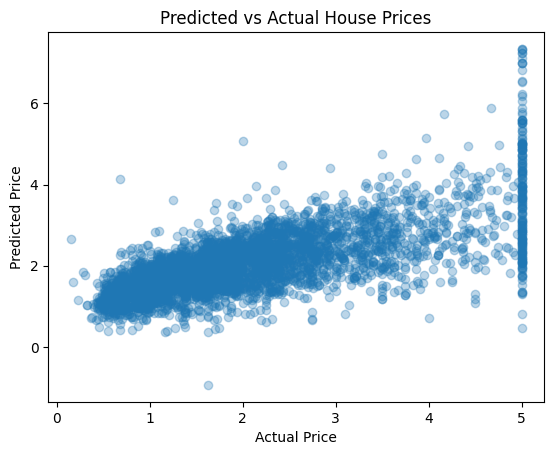

In [7]:
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual House Prices')
plt.show()

Mere model ka R² score 0.50 hai, jiska seedha matlab yeh hai ke yeh model ghar ki price mein hone wale farq ka taqreeban 50% samjha pa raha hai — sirf income, rooms ki tadaad, ghar ki age, occupants, aur population jaise 5 factors ki madad se. Baaki 50% aise factors pe depend karta hai jo humne is model mein shamil nahi kiye, jaise ghar ka exact location, uski condition, ya neighborhood ki quality. Yeh ek theek-thaak model hai — kaam ka hai lekin perfect price predict nahi kar sakta, aur behtar banane ke liye humein aur features (jaise location) shamil karne honge.